In [13]:
"""
F1 ADVANCED HEATMAPS
5 Professional Visualizations for Race Analysis

"""

import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import cm
import seaborn as sns

# Setup
fastf1.plotting.setup_mpl()
fastf1.Cache.enable_cache('/workspaces/f1-race-analysis/data/raw')


# SETUP: CARREGAR DADOS


print("🏎️  Carregando sessão...")
session = fastf1.get_session(2025, 'São Paulo', 'R')
session.load()

# Pilotos para análise # None se quiser automático, entao pega P1 e P2
SELECTED_DRIVERS = ["VER", "NOR"] 

if SELECTED_DRIVERS and len(SELECTED_DRIVERS) == 2:
    driver_1, driver_2 = SELECTED_DRIVERS
else:
    driver_1 = session.results.iloc[0]['Abbreviation']
    driver_2 = session.results.iloc[1]['Abbreviation']


# Voltas mais rápidas
fastest_1 = session.laps.pick_driver(driver_1).pick_fastest()
fastest_2 = session.laps.pick_driver(driver_2).pick_fastest()

# Telemetria
tel_1 = fastest_1.get_telemetry()
tel_2 = fastest_2.get_telemetry()

print(f"✅ Comparando: {driver_1} vs {driver_2}\n")

core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


🏎️  Carregando sessão...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '12', '1', '63', '81', '87', '30', '6', '27', '10', '23', '31', '55', '14', '43', '18', '22', '44', '16', '5']
/workspaces/f1-race-analysis/f1-env/lib/python3.12/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/workspaces/f1-race-analysis/f1-env/lib/python3.12/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver 

✅ Comparando: VER vs NOR



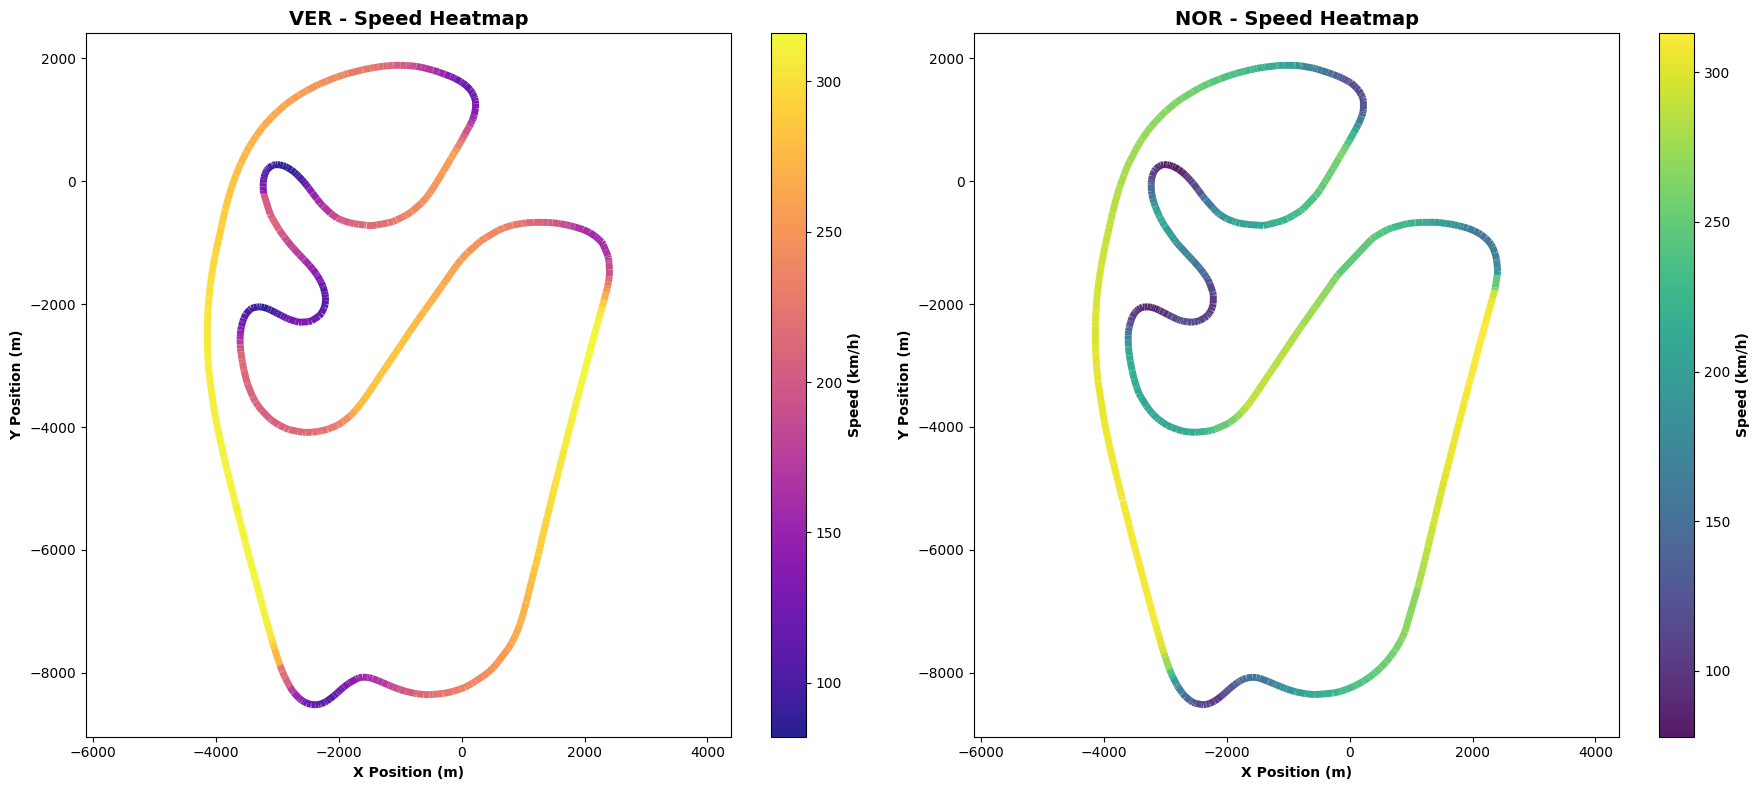

✅ Heatmap 1 salvo: speed_classic.png



In [14]:

# HEATMAP 1: SPEED (CLASSIC)


def create_speed_heatmap(telemetry, driver_name, ax, colormap='plasma'):
    """
    Heatmap clássico de velocidade
    """
    x = telemetry['X'].values
    y = telemetry['Y'].values
    speed = telemetry['Speed'].values
    
    # Criar segmentos
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Criar LineCollection
    norm = plt.Normalize(speed.min(), speed.max())
    lc = LineCollection(segments, cmap=colormap, norm=norm, linewidth=5, alpha=0.9)
    lc.set_array(speed)
    
    line = ax.add_collection(lc)
    
    # Styling
    ax.set_xlabel('X Position (m)', fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontweight='bold')
    ax.set_title(f'{driver_name} - Speed Heatmap', fontsize=14, fontweight='bold')
    ax.axis('equal')
    
    # Colorbar
    cbar = plt.colorbar(line, ax=ax)
    cbar.set_label('Speed (km/h)', fontweight='bold')
    
    return ax

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
create_speed_heatmap(tel_1, driver_1, axes[0], 'plasma')
create_speed_heatmap(tel_2, driver_2, axes[1], 'viridis')
plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/heatmap_01_speed_classic.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Heatmap 1 salvo: speed_classic.png\n")

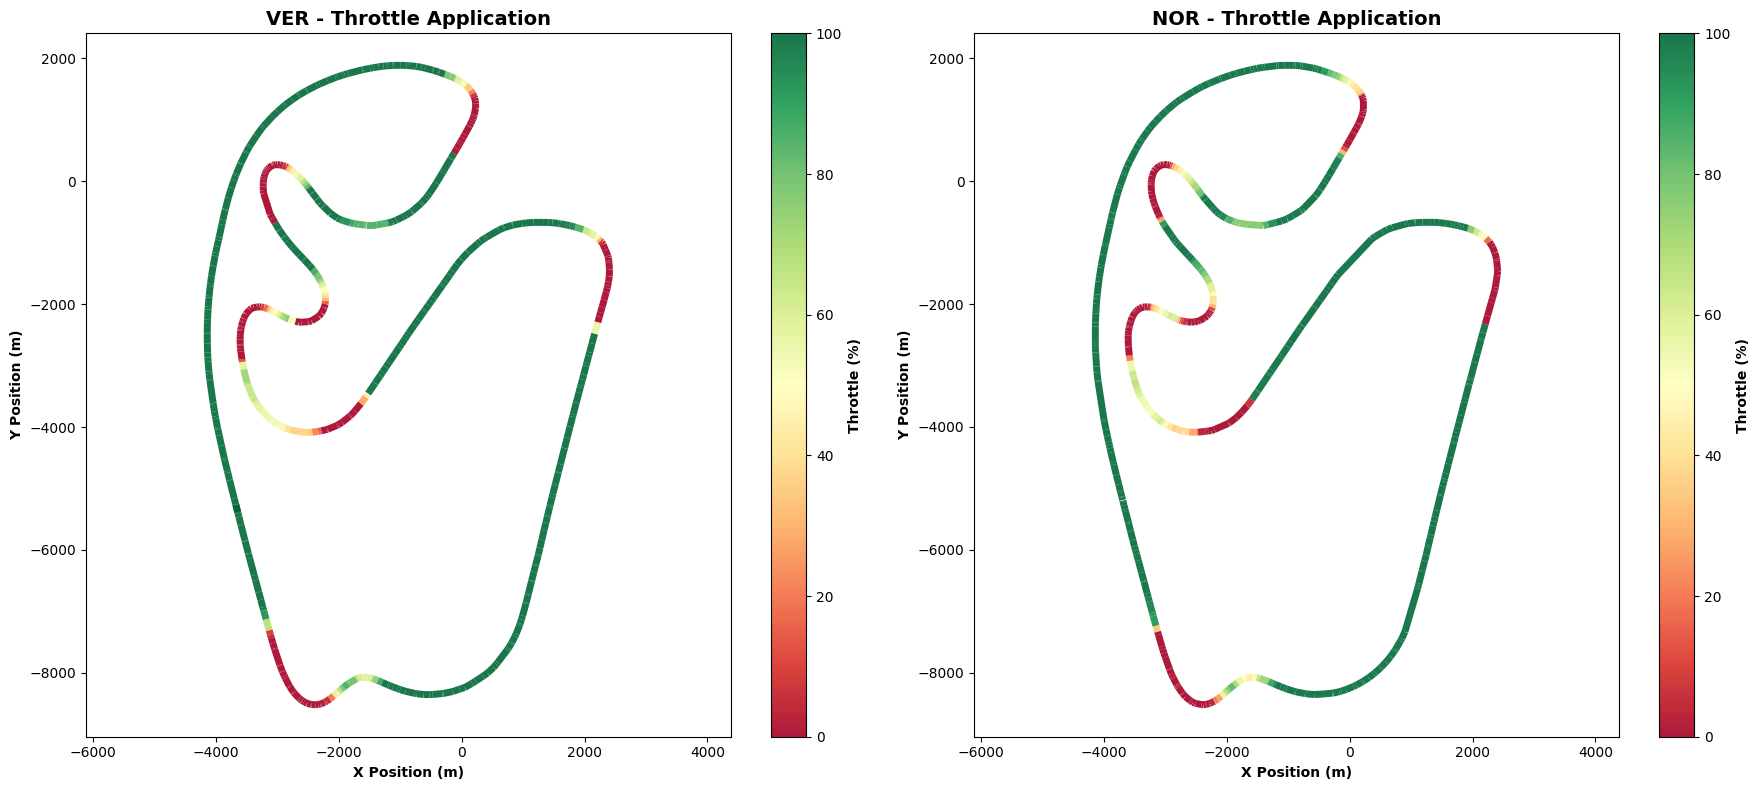

✅ Heatmap 2 salvo: throttle_application.png



In [15]:

# HEATMAP 2: THROTTLE APPLICATION


def create_throttle_heatmap(telemetry, driver_name, ax):
    """
    Heatmap de aplicação de acelerador (onde piloto acelera mais)
    """
    x = telemetry['X'].values
    y = telemetry['Y'].values
    throttle = telemetry['Throttle'].values
    
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Colormap customizado: verde (100%) → amarelo (50%) → vermelho (0%)
    norm = plt.Normalize(0, 100)
    lc = LineCollection(segments, cmap='RdYlGn', norm=norm, linewidth=5, alpha=0.9)
    lc.set_array(throttle)
    
    line = ax.add_collection(lc)
    
    ax.set_xlabel('X Position (m)', fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontweight='bold')
    ax.set_title(f'{driver_name} - Throttle Application', fontsize=14, fontweight='bold')
    ax.axis('equal')
    
    cbar = plt.colorbar(line, ax=ax)
    cbar.set_label('Throttle (%)', fontweight='bold')
    
    return ax

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
create_throttle_heatmap(tel_1, driver_1, axes[0])
create_throttle_heatmap(tel_2, driver_2, axes[1])
plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/heatmap_02_throttle.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Heatmap 2 salvo: throttle_application.png\n")

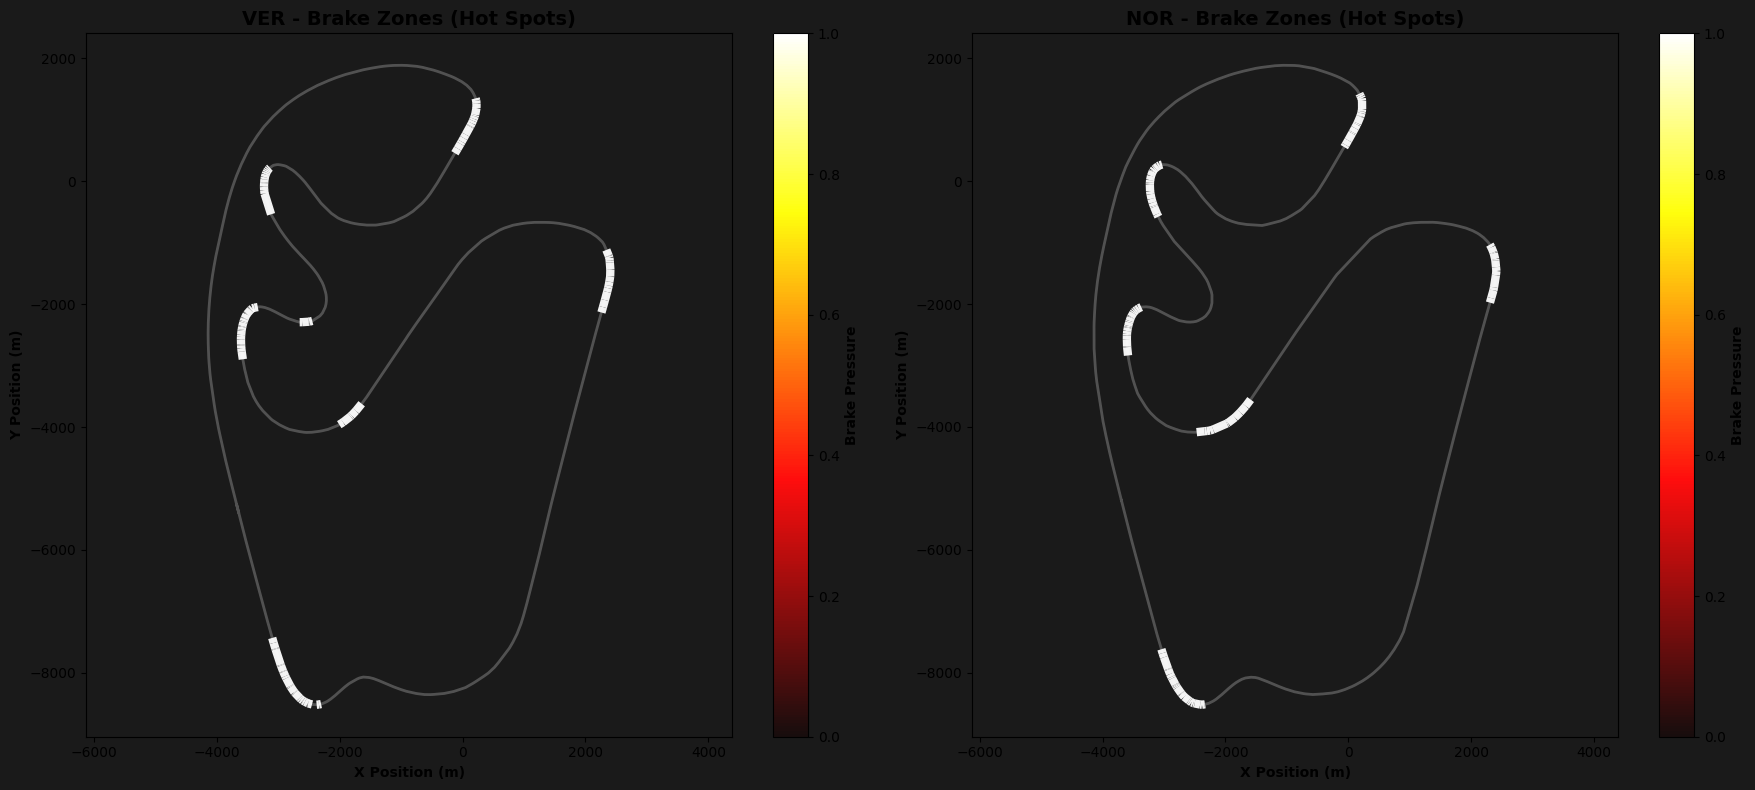

✅ Heatmap 3 salvo: brake_zones.png



In [16]:

# HEATMAP 3: BRAKE ZONES (HOT SPOTS)


def create_brake_heatmap(telemetry, driver_name, ax):
    """
    Mostra zonas de frenagem (vermelho intenso = freio pesado)
    """
    x = telemetry['X'].values
    y = telemetry['Y'].values
    brake = telemetry['Brake'].values
    
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Apenas mostrar onde há frenagem (>0)
    brake_filtered = np.where(brake > 0, brake, np.nan)
    
    norm = plt.Normalize(0, 1)
    lc = LineCollection(segments, cmap='hot', norm=norm, linewidth=6, alpha=0.95)
    lc.set_array(brake_filtered)
    
    line = ax.add_collection(lc)
    
    # Background: linha cinza para contexto da pista
    ax.plot(x, y, color='lightgray', linewidth=2, alpha=0.3, zorder=0)
    
    ax.set_xlabel('X Position (m)', fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontweight='bold')
    ax.set_title(f'{driver_name} - Brake Zones (Hot Spots)', 
                 fontsize=14, fontweight='bold')
    ax.axis('equal')
    ax.set_facecolor('#1a1a1a')  # Fundo escuro para destaque
    
    cbar = plt.colorbar(line, ax=ax)
    cbar.set_label('Brake Pressure', fontweight='bold')
    
    return ax

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
create_brake_heatmap(tel_1, driver_1, axes[0])
create_brake_heatmap(tel_2, driver_2, axes[1])
fig.patch.set_facecolor('#1a1a1a')
plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/heatmap_03_brake_zones.png', dpi=300, 
            bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
print("✅ Heatmap 3 salvo: brake_zones.png\n")

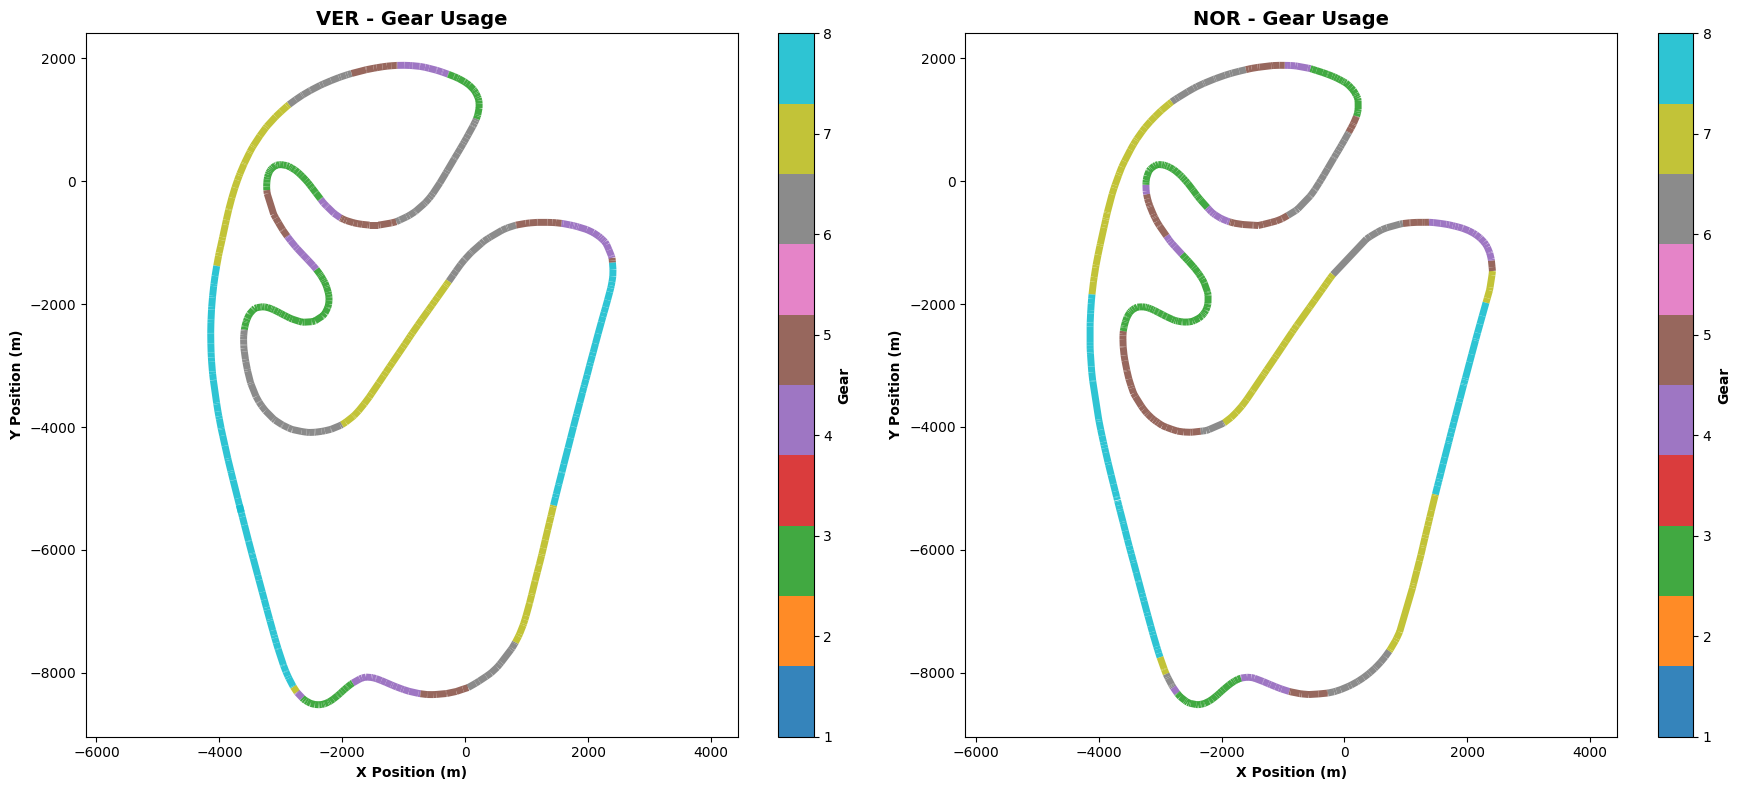

✅ Heatmap 4 salvo: gear_usage.png



In [17]:

# HEATMAP 4: GEAR USAGE (DISCRETE COLORS)


def create_gear_heatmap(telemetry, driver_name, ax):
    """
    Mostra marchas usadas ao longo da pista (cores discretas)
    """
    x = telemetry['X'].values
    y = telemetry['Y'].values
    gear = telemetry['nGear'].values
    
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Colormap discreto (cada marcha = cor diferente)
    norm = plt.Normalize(1, 8)
    lc = LineCollection(segments, cmap='tab10', norm=norm, linewidth=5, alpha=0.9)
    lc.set_array(gear)
    
    line = ax.add_collection(lc)
    
    ax.set_xlabel('X Position (m)', fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontweight='bold')
    ax.set_title(f'{driver_name} - Gear Usage', fontsize=14, fontweight='bold')
    ax.axis('equal')
    
    cbar = plt.colorbar(line, ax=ax, ticks=range(1, 9))
    cbar.set_label('Gear', fontweight='bold')
    
    return ax

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
create_gear_heatmap(tel_1, driver_1, axes[0])
create_gear_heatmap(tel_2, driver_2, axes[1])
plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/heatmap_04_gear_usage.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Heatmap 4 salvo: gear_usage.png\n")

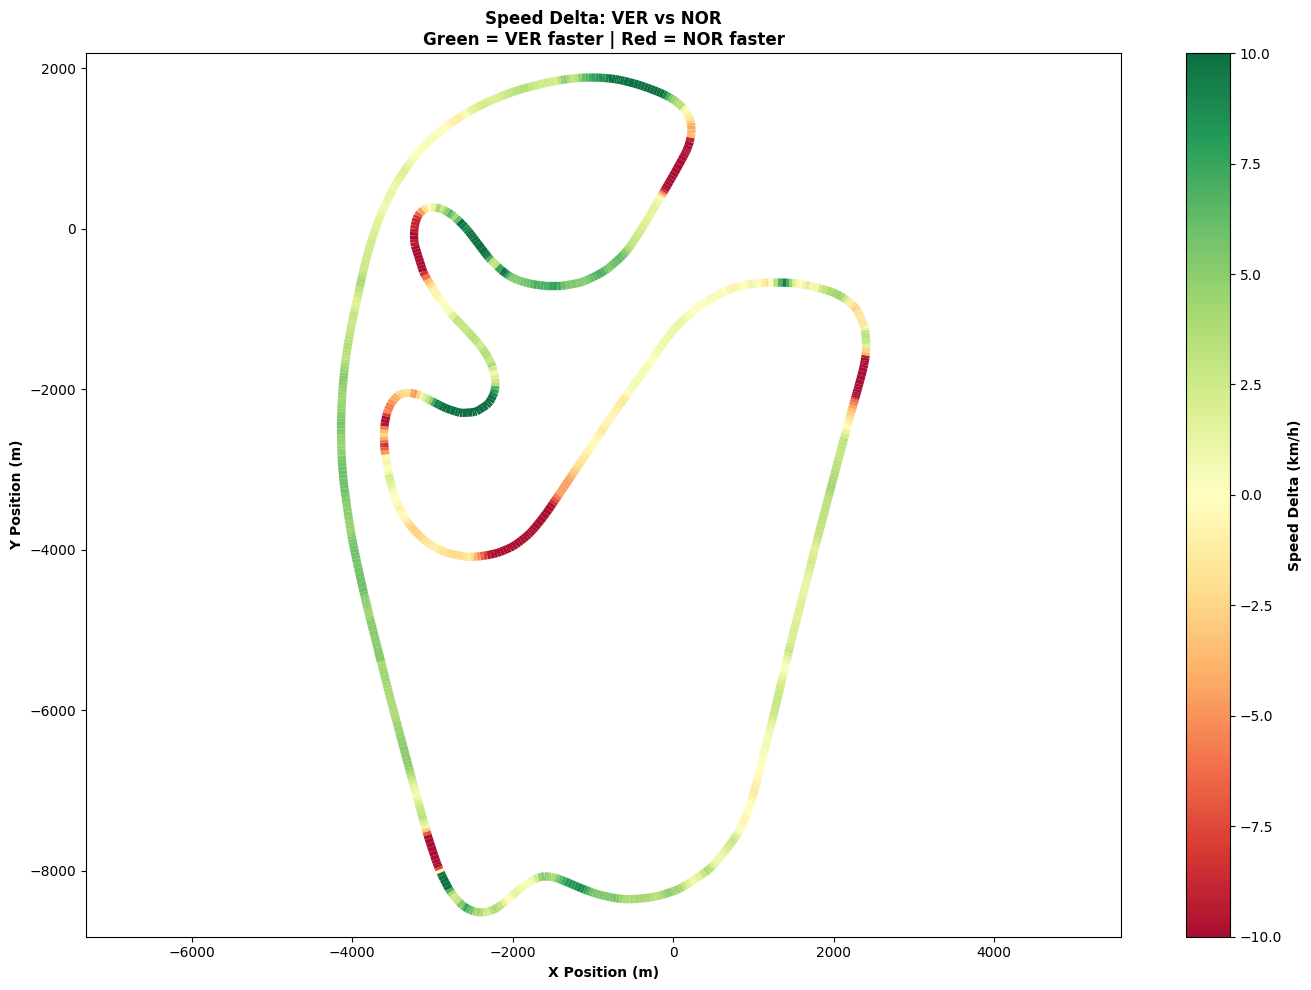

✅ Heatmap 5 salvo: delta_comparison.png



In [18]:

# HEATMAP 5: DELTA COMPARISON (ADVANCED)


def create_delta_heatmap(tel_1, tel_2, driver_1, driver_2, ax):
    """
    Mostra ONDE um piloto é mais rápido que o outro
    Verde = driver_1 mais rápido | Vermelho = driver_2 mais rápido
    """
    from scipy.interpolate import interp1d
    
    # Criar grid comum de distância
    max_dist = min(tel_1['Distance'].max(), tel_2['Distance'].max())
    common_dist = np.linspace(0, max_dist, 1000)
    
    # Interpolar velocidades
    speed_interp_1 = interp1d(tel_1['Distance'], tel_1['Speed'], 
                              kind='linear', fill_value='extrapolate')
    speed_interp_2 = interp1d(tel_2['Distance'], tel_2['Speed'], 
                              kind='linear', fill_value='extrapolate')
    
    speed_1_common = speed_interp_1(common_dist)
    speed_2_common = speed_interp_2(common_dist)
    
    # Delta (positivo = driver_1 mais rápido)
    delta = speed_1_common - speed_2_common
    
    # Interpolar posições X, Y
    x_interp_1 = interp1d(tel_1['Distance'], tel_1['X'], 
                          kind='linear', fill_value='extrapolate')
    y_interp_1 = interp1d(tel_1['Distance'], tel_1['Y'], 
                          kind='linear', fill_value='extrapolate')
    
    x_common = x_interp_1(common_dist)
    y_common = y_interp_1(common_dist)
    
    # Criar segmentos
    points = np.array([x_common, y_common]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Colormap divergente
    norm = plt.Normalize(-10, 10)  # ±10 km/h
    lc = LineCollection(segments, cmap='RdYlGn', norm=norm, linewidth=6, alpha=0.95)
    lc.set_array(delta)
    
    line = ax.add_collection(lc)
    
    # Labels e título (CORRIGIDO)
    ax.set_xlabel('X Position (m)', fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontweight='bold')
    ax.set_title(
        f'Speed Delta: {driver_1} vs {driver_2}\n'
        f'Green = {driver_1} faster | Red = {driver_2} faster', 
        fontsize=12, fontweight='bold'
    )
    ax.axis('equal')
    
    cbar = plt.colorbar(line, ax=ax)
    cbar.set_label('Speed Delta (km/h)', fontweight='bold')
    
    return ax

# Usar
fig, ax = plt.subplots(figsize=(14, 10))
create_delta_heatmap(tel_1, tel_2, driver_1, driver_2, ax)
plt.tight_layout()
plt.savefig('/workspaces/f1-race-analysis/figures/heatmap_05_delta_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Heatmap 5 salvo: delta_comparison.png\n")

🎨 Criando visualização combinada...



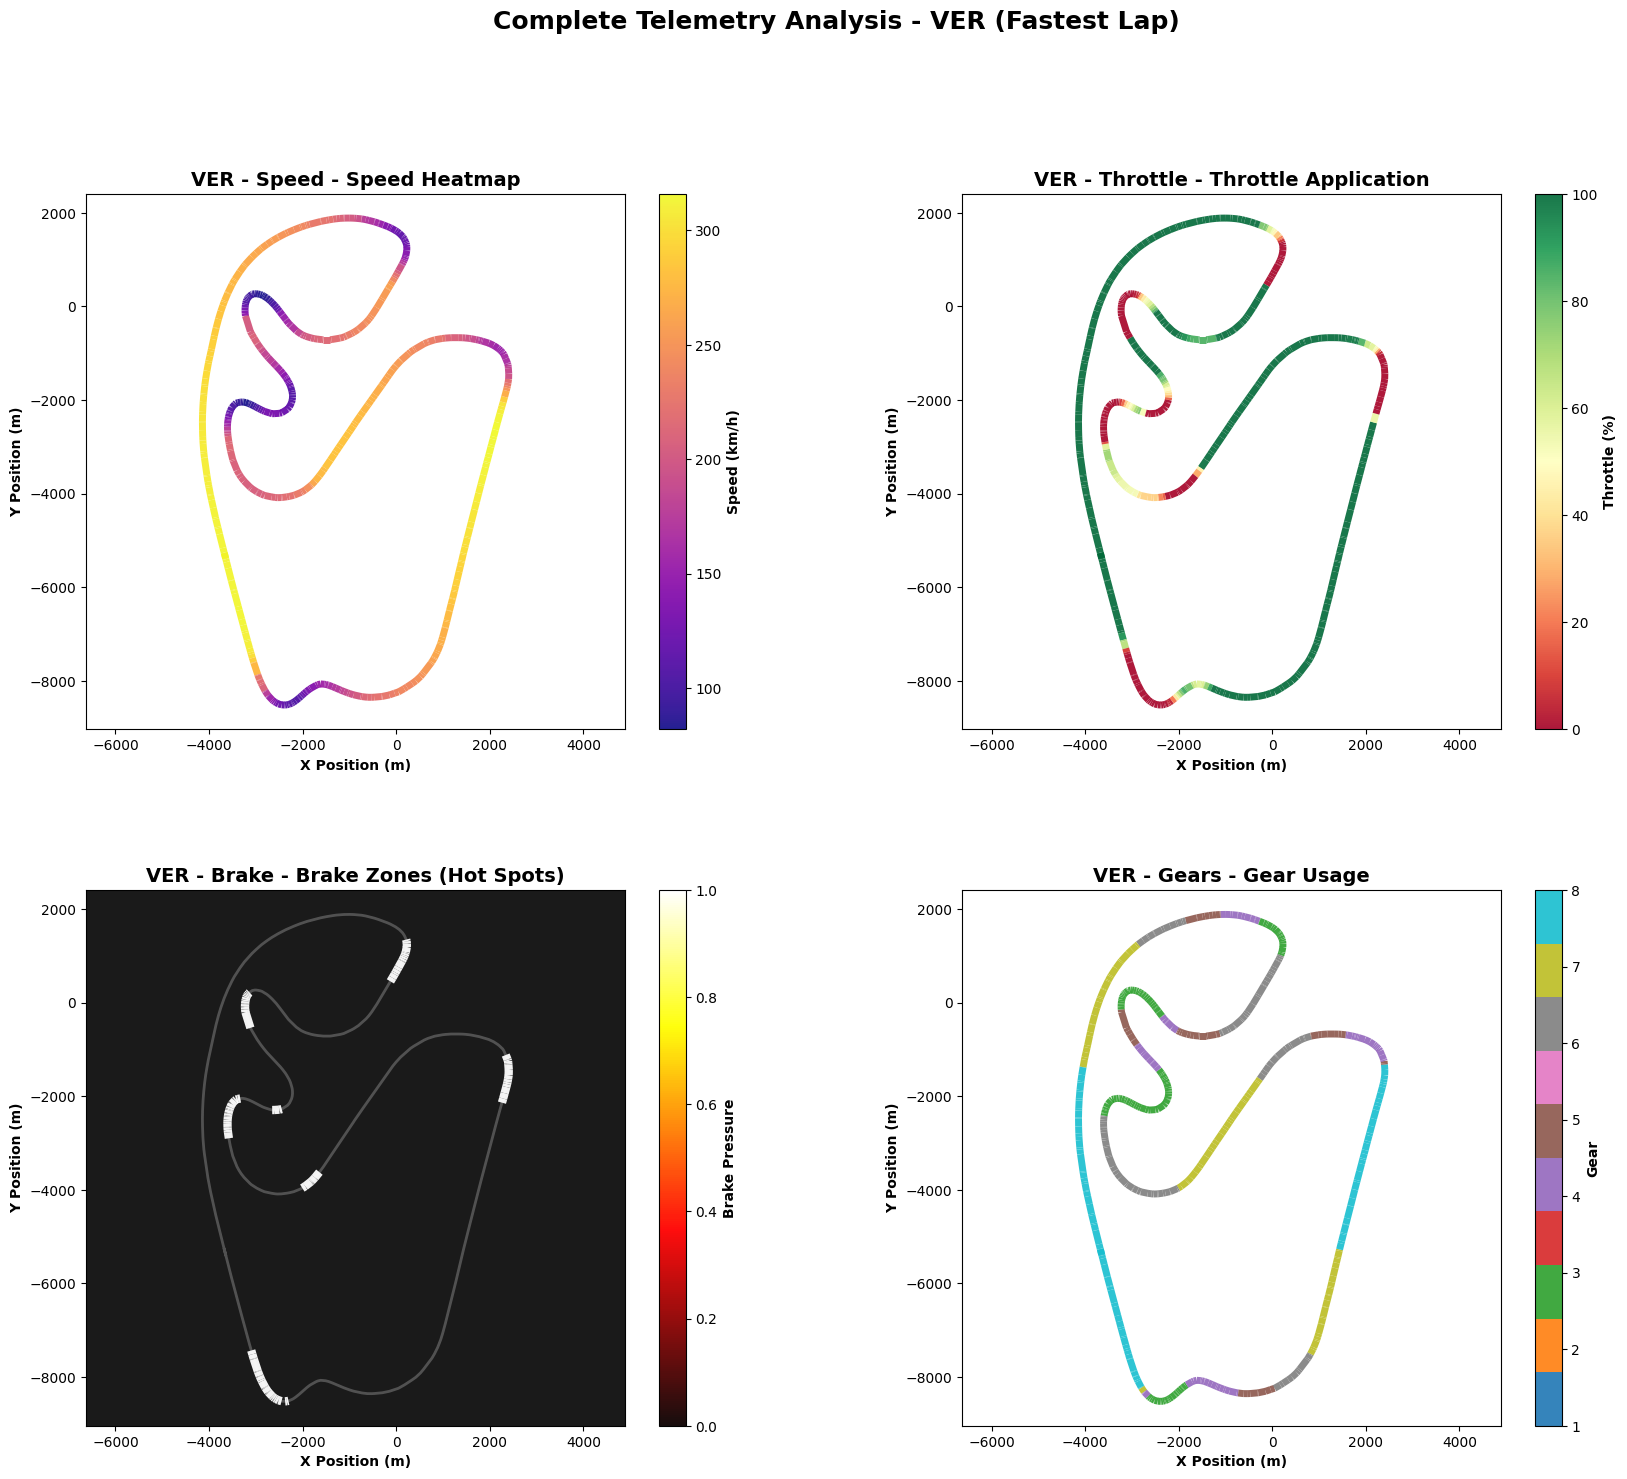

✅ Bonus combinado salvo: combined_view.png



In [19]:

# BONUS: COMBINED VIEW (4 HEATMAPS EM 1 FIGURA)


print("🎨 Criando visualização combinada...\n")

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Speed
ax1 = fig.add_subplot(gs[0, 0])
create_speed_heatmap(tel_1, f'{driver_1} - Speed', ax1, 'plasma')

# Throttle
ax2 = fig.add_subplot(gs[0, 1])
create_throttle_heatmap(tel_1, f'{driver_1} - Throttle', ax2)

# Brake
ax3 = fig.add_subplot(gs[1, 0])
create_brake_heatmap(tel_1, f'{driver_1} - Brake', ax3)

# Gear
ax4 = fig.add_subplot(gs[1, 1])
create_gear_heatmap(tel_1, f'{driver_1} - Gears', ax4)

fig.suptitle(f'Complete Telemetry Analysis - {driver_1} (Fastest Lap)', 
             fontsize=18, fontweight='bold', y=0.995)

plt.savefig('/workspaces/f1-race-analysis/figures/heatmap_bonus_combined.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Bonus combinado salvo: combined_view.png\n")

In [11]:

# RESUMO


print("="*70)
print("🏁 HEATMAPS CRIADOS COM SUCESSO!")
print("="*70)
print("\n📊 6 visualizações geradas:")
print("  1. Speed (Classic) - Velocidade ao longo da pista")
print("  2. Throttle - Aplicação de acelerador")
print("  3. Brake Zones - Zonas de frenagem (hot spots)")
print("  4. Gear Usage - Marchas utilizadas")
print("  5. Delta Comparison - Onde cada piloto é mais rápido")
print("  6. Combined View - 4 heatmaps em 1 figura")
print("\n📁 Salvos em: figures/")
print("\n💡 Use esses heatmaps em:")
print("  - Apresentações técnicas")
print("  - Portfolio GitHub")
print("  - Posts LinkedIn")
print("  - Artigos técnicos")
print("\n🎯 Próximo nível: Adicione corner numbers e DRS zones!")

🏁 HEATMAPS CRIADOS COM SUCESSO!

📊 6 visualizações geradas:
  1. Speed (Classic) - Velocidade ao longo da pista
  2. Throttle - Aplicação de acelerador
  3. Brake Zones - Zonas de frenagem (hot spots)
  4. Gear Usage - Marchas utilizadas
  5. Delta Comparison - Onde cada piloto é mais rápido
  6. Combined View - 4 heatmaps em 1 figura

📁 Salvos em: figures/

💡 Use esses heatmaps em:
  - Apresentações técnicas
  - Portfolio GitHub
  - Posts LinkedIn
  - Artigos técnicos

🎯 Próximo nível: Adicione corner numbers e DRS zones!
